## Preprocessing with read_csv

In [3]:
import pandas as pd

In [12]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns)

In [14]:
oil.head()

,Date,Oil Price
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


## Column Selection

In [30]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=True,
                 usecols=['Date', 'Oil Price'] #for selecting which columns you would like to see
                 )


In [32]:
oil.head()

,Oil Price
Date,
2013-01-01,NaN
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20


## Row Selection & Missing Values

In [46]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=True,
                 usecols=['Date', 'Oil Price'], #for selecting which columns you would like to see
                 skiprows=[0], #skips the rows from the dataframe
                 nrows = 3
                 )

oil.head()


,Oil Price
Date,
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12


In [48]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=True,
                 usecols=['Date', 'Oil Price'], #for selecting which columns you would like to see
                 #skiprows=[0], #skips the rows from the dataframe
                 nrows = 3,
                 skiprows = lambda x: x % 2 == 1
                 )

oil.head()


,Oil Price
Date,
2013-01-02,93.14
2013-01-04,93.12
2013-01-08,93.21


In [53]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=True,
                 usecols=['Date', 'Oil Price'], #for selecting which columns you would like to see
                 #skiprows=[0], #skips the rows from the dataframe
                 #nrows = 3,
                 #skiprows = lambda x: x % 2 == 1
                 na_values = 93.14 # if the given value is found, it replaces with NaN. You can also give list of values to be NaN
                 )

oil.head()


,Oil Price
Date,
2013-01-01,NaN
2013-01-02,NaN
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20


### Demo

In [ ]:
import pandas as pd

# Load the dataset with specified columns, skipping rows, handling missing values, and limiting the number of rows
crypto = pd.read_csv('cryptocurrency_BTC.csv',
                    usecols = ['Date', 'Close', 'Volume'],
                    skiprows =[1],
                    na_values = ['.', 'MISSING'],
                    nrows = 5
                    )


# Display the DataFrame to verify loading and handling of missing values
crypto

## Converters

In [73]:
columns = ['Date', 'Oil Price']
string_slice = lambda x: int(x[-2:])


oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=['Date'],
                 infer_datetime_format = True,
                 dtype = {'Oil Price': 'float'},
                 converters={'Date': string_slice}
                 )

oil.head()


C:\Users\Pain\AppData\Local\Temp\ipykernel_3024\1516902548.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
C:\Users\Pain\AppData\Local\Temp\ipykernel_3024\1516902548.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",


,Oil Price
Date,
1,NaN
2,93.14
3,92.97
4,93.12
7,93.20


## Assignment 1 Importing Data

In [178]:
columns = ['Date', 'Store_Number', 'Transaction_Count']

# target_pct = lambda x: (x["Transaction_Count"] / 2500)
# met_target = lambda x: ((x["Transaction_Count"] / 2500) >= 1) 
# bonus_payable = lambda x: ((x["Transaction_Count"] / 2500) >= 1) * 100
# month = lambda x: x['Date'].dt.month
# day_of_week = lambda x: x['Date'].dt.dayofweek


transactions = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\transactions.csv",
                           parse_dates=['Date'],
                           header=0,
                           names=columns,
                           skiprows=[0],
                           dtype={'Store_Number': 'int8', 'Transaction_Count': 'int16'}
                          ).assign(
                           target_pct = lambda x: (x["Transaction_Count"] / 2500),
                           met_target = lambda x: ((x["Transaction_Count"] / 2500) >= 1), 
                           bonus_payable = lambda x: (x["Transaction_Count"] / 2500) >= 1 * 100,
                           month = lambda x: x['Date'].dt.month,
                           day_of_week = lambda x: x['Date'].dt.dayofweek
                          ).astype(
                           {
                               'target_pct': 'float32', 
                               'month': 'int8', 
                               'day_of_week': 'int8'
                           }
                          )

In [179]:
transactions

,Date,Store_Number,Transaction_Count,target_pct,met_target,bonus_payable,month,day_of_week
0,2013-01-02,1,2111,0.8444,False,False,1,2
1,2013-01-02,2,2358,0.9432,False,False,1,2
2,2013-01-02,3,3487,1.3948,True,False,1,2
3,2013-01-02,4,1922,0.7688,False,False,1,2
4,2013-01-02,5,1903,0.7612,False,False,1,2
...,...,...,...,...,...,...,...,...
83482,2017-08-15,50,2804,1.1216,True,False,8,1
83483,2017-08-15,51,1573,0.6292,False,False,8,1
83484,2017-08-15,52,2255,0.9020,False,False,8,1
83485,2017-08-15,53,932,0.3728,False,False,8,1


In [182]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83487 entries, 0 to 83486
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               83487 non-null  datetime64[ns]
 1   Store_Number       83487 non-null  int8          
 2   Transaction_Count  83487 non-null  int16         
 3   target_pct         83487 non-null  float32       
 4   met_target         83487 non-null  bool          
 5   bonus_payable      83487 non-null  bool          
 6   month              83487 non-null  int8          
 7   day_of_week        83487 non-null  int8          
dtypes: bool(2), datetime64[ns](1), float32(1), int16(1), int8(3)
memory usage: 1.5 MB


## Parsing Dates & Data Types

In [190]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=['Date'], # you can list more date columns
                 infer_datetime_format = True
                 )

oil.head()


C:\Users\Pain\AppData\Local\Temp\ipykernel_3024\2364812198.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",


,Oil Price
Date,
2013-01-01,NaN
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20


In [192]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1218 entries, 2013-01-01 to 2017-08-31
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Oil Price  1175 non-null   float64
dtypes: float64(1)
memory usage: 19.0 KB


In [198]:
columns = ['Date', 'Oil Price']

oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",
                 header = 0,
                 names = columns,
                 index_col = 'Date',
                 parse_dates=['Date'], # you can list more date columns
                 infer_datetime_format = True,
                 dtype = {'Oil Price': 'float32'}
                 )

oil.head()


C:\Users\Pain\AppData\Local\Temp\ipykernel_3024\2499851144.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  oil = pd.read_csv(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\retail\oil.csv",


,Oil Price
Date,
2013-01-01,NaN
2013-01-02,93.139999
2013-01-03,92.970001
2013-01-04,93.120003
2013-01-07,93.199997


In [200]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1218 entries, 2013-01-01 to 2017-08-31
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Oil Price  1175 non-null   float32
dtypes: float32(1)
memory usage: 14.3 KB


### Demo

In [ ]:
import pandas as pd


# Load the dataset with specified columns and data types
crypto = pd.read_csv('cryptocurrency_BTC', 
                     parse_dates=['Date'],
                     infer_datetime_format = True,
                     dtype={
                         'Open': 'int32',
                         'High': 'int32',
                         'Low': 'int32',
                         'Close': 'int32',
                         'Adj Close': 'int64',  
                     }
                    
                    )


# Display the DataFrame to verify loading and data types
crypto

## Importing from Text & Excel Files

In [205]:
pd.read_excel(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\project_data\premier_league_games_full.xlsx")

,id,league_name,season,HomeTeam,AwayTeam,HomeGoals,AwayGoals
0,1729,England Premier League,2008/2009,Manchester United,Newcastle United,1,1
1,1730,England Premier League,2008/2009,Arsenal,West Bromwich Albion,1,0
2,1731,England Premier League,2008/2009,Sunderland,Liverpool,0,1
3,1732,England Premier League,2008/2009,West Ham United,Wigan Athletic,2,1
4,1733,England Premier League,2008/2009,Aston Villa,Manchester City,4,2
...,...,...,...,...,...,...,...
3035,4764,England Premier League,2015/2016,Southampton,Leicester City,2,2
3036,4765,England Premier League,2015/2016,Swansea City,Stoke City,0,1
3037,4766,England Premier League,2015/2016,Tottenham Hotspur,Liverpool,0,0
3038,4767,England Premier League,2015/2016,Watford,Arsenal,0,3


In [209]:
pd.read_excel(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\project_data\premier_league_games.xlsx",
             sheet_name = 1)

,id,league_name,season,HomeGoals,AwayGoals
0,2109,England Premier League,2009/2010,1,0
1,2110,England Premier League,2009/2010,2,1
2,2111,England Premier League,2009/2010,0,2
3,2112,England Premier League,2009/2010,1,6
4,2113,England Premier League,2009/2010,0,2
...,...,...,...,...,...
375,2484,England Premier League,2009/2010,2,1
376,2485,England Premier League,2009/2010,1,0
377,2486,England Premier League,2009/2010,1,1
378,2487,England Premier League,2009/2010,1,2


In [215]:
pd.read_excel(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\project_data\premier_league_games.xlsx",
             sheet_name = '2009_2010')

,id,league_name,season,HomeGoals,AwayGoals
0,2109,England Premier League,2009/2010,1,0
1,2110,England Premier League,2009/2010,2,1
2,2111,England Premier League,2009/2010,0,2
3,2112,England Premier League,2009/2010,1,6
4,2113,England Premier League,2009/2010,0,2
...,...,...,...,...,...
375,2484,England Premier League,2009/2010,2,1
376,2485,England Premier League,2009/2010,1,0
377,2486,England Premier League,2009/2010,1,1
378,2487,England Premier League,2009/2010,1,2


In [223]:
pd.concat(
    pd.read_excel(r"D:\Self_Study\Udemy\Python\Python Data Analysis NumPy & Pandas Masterclass\Pandas+Course+Resources\Pandas Course Resources\project_data\premier_league_games.xlsx",
                 sheet_name = None),
                 ignore_index = True
)

,id,league_name,season,HomeGoals,AwayGoals
0,1729,England Premier League,2008/2009,1,1
1,1730,England Premier League,2008/2009,1,0
2,1731,England Premier League,2008/2009,0,1
3,1732,England Premier League,2008/2009,2,1
4,1733,England Premier League,2008/2009,4,2
...,...,...,...,...,...
755,2484,England Premier League,2009/2010,2,1
756,2485,England Premier League,2009/2010,1,0
757,2486,England Premier League,2009/2010,1,1
758,2487,England Premier League,2009/2010,1,2


## Exporting to Flat Files

In [ ]:
df.to_csv('cleaned_data.csv')  #CSV Export

In [ ]:
df.to_csv('cleaned_data.txt', sep='\t')  # TXT Export

In [ ]:
df.to_excel('cleaned_data.xlsx', sheet_name='October_Sales')   #Excel Export

In [ ]:
#To export multiple sheets at the same time use below code:

with pd.ExcelWriter('cleaned_data.xlsx') as writer:
    df.to_excel(writer, sheet_name='October_Sales')
    df.to_excel(writer, sheet_name='November_Sales')


### Demo

In [ ]:
import pandas as pd

# Load the dataset
crypto = pd.read_csv('cryptocurrency_BTC.csv', parse_dates = ['Date'])

# Save the dataset to a tab-separated text file
crpto.to_csv('cryptocurrency_BTC.txt', index=False, sep='\t')

# Display the DataFrame to verify the data
crypto


### Assignment 2

In [231]:
transactions.head()

,Date,Store_Number,Transaction_Count,target_pct,met_target,bonus_payable,month,day_of_week
0,2013-01-02,1,2111,0.8444,False,False,1,2
1,2013-01-02,2,2358,0.9432,False,False,1,2
2,2013-01-02,3,3487,1.3948,True,False,1,2
3,2013-01-02,4,1922,0.7688,False,False,1,2
4,2013-01-02,5,1903,0.7612,False,False,1,2


In [250]:
transactions_2013 = transactions[transactions['Date'].dt.year == 2013]
transactions_2014 = transactions[transactions['Date'].dt.year == 2014]
transactions_2015 = transactions[transactions['Date'].dt.year == 2015]
transactions_2016 = transactions[transactions['Date'].dt.year == 2016]
transactions_2017 = transactions[transactions['Date'].dt.year == 2017]


with pd.ExcelWriter('transactions.xlsx') as writer:
    transactions_2013.to_excel(writer, sheet_name='transactions_2013')
    transactions_2014.to_excel(writer, sheet_name='transactions_2014')
    transactions_2015.to_excel(writer, sheet_name='transactions_2015')
    transactions_2016.to_excel(writer, sheet_name='transactions_2016')
    transactions_2017.to_excel(writer, sheet_name='transactions_2017')


In [254]:
# Better version of the above code

with pd.ExcelWriter('transactions.xlsx') as writer:
    for year in range(2013, 2018):
        transactions.loc[transactions['Date'].dt.year == year].to_excel(
            writer, sheet_name=str(year)
        )

In [258]:
# Better version of the above code with Formatted Sheet name 

for year in range(2013, 2018):
    transactions.loc[transactions['Date'].dt.year == year].to_csv(
        f"transactions_{year}.csv"
    )

## Working With SQL Databases

In [ ]:
import pandas as pd 
from sqlalchemy import create_engine, inspect

In [ ]:
engine = create_engine("sqlite:///../soccer_database.sqlite")

inspect(engine).get_table_names()

In [ ]:
pd.read_sql("SELECT * FROM player", engine) # Here you can write any level of SQL query

## Other Supported File Formats

In [272]:
import pandas as pd

url = 'https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_GDP'

gdp_data = pd.read_html(url)[0]


In [274]:
gdp_data.head()

State or federal district  \
  State or federal district   
0                California   
1                     Texas   
2                  New York   
3                   Florida   
4                  Illinois   

  Nominal GDP at current prices 2024 (millions of U.S. dollars)[1]           \
                                                              2022     2024   
0                                            3641643                4103124   
1                                            2402137                2709393   
2                                            2048403                2297028   
3                                            1439065                1705565   
4                                            1025667                1137244   

  Annual GDP change at current prices (2023–2024)[1]  \
  Annual GDP change at current prices (2023–2024)[1]   
0                                             438535   
1                                             292387   
2                                             235961   
3                                             256208   
4                                             106476   

                                                        \
  Annual GDP change at current prices (2023–2024)[1].1   
0                                               5.7%     
1                                               6.0%     
2                                               5.8%     
3                                               9.2%     
4                                               5.6%     

  Real GDP growth rate (2023–2024)[1] Nominal GDP per capita[1][2]            \
  Real GDP growth rate (2023–2024)[1]                         2022      2024   
0                                2.0%                      $93,460  $104,916   
1                                7.4%                      $78,750   $86,987   
2                                1.5%                     $104,660  $117,332   
3                                4.3%                      $63,640   $73,784   
4                                1.0%                      $81,730   $90,449   

  % of national[1]          
              2022    2024  
0           14.69%  14.14%  
1            8.69%   9.34%  
2            8.11%   7.92%  
3            5.37%   5.87%  
4            4.11%   3.92%

In [276]:
gdp_data = (gdp_data
            .droplevel(level = 0, axis = 1)
            .drop(index=0)
)


In [278]:
gdp_data.head()

,State or federal district,2022,2024,Annual GDP change at current prices (2023–2024)[1],Annual GDP change at current prices (2023–2024)[1].1,Real GDP growth rate (2023–2024)[1],2022,2024,2022,2024
1,Texas,2402137,2709393,292387,6.0%,7.4%,"$78,750","$86,987",8.69%,9.34%
2,New York,2048403,2297028,235961,5.8%,1.5%,"$104,660","$117,332",8.11%,7.92%
3,Florida,1439065,1705565,256208,9.2%,4.3%,"$63,640","$73,784",5.37%,5.87%
4,Illinois,1025667,1137244,106476,5.6%,1.0%,"$81,730","$90,449",4.11%,3.92%
5,Pennsylvania,911813,1024206,105444,6.2%,2.5%,"$70,350","$78,544",3.67%,3.52%


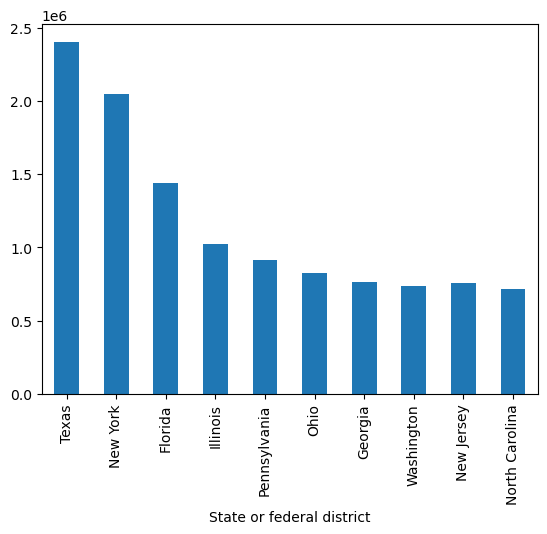

In [284]:
(gdp_data
 .set_index('State or federal district')
 .iloc[:10, 0]
 .plot.bar()
);